# 🖥️ Laptop Dataset Analysis & Price Prediction
> **Topic:** Performing Analysis on Laptop Dataset  
> Covers: Data Cleaning · EDA · Feature Engineering · Classification · Regression

## 1. Import Libraries

In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, mean_absolute_error,
    mean_squared_error, r2_score
)

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Libraries imported successfully ✔")

Libraries imported successfully ✔


## 2. Load Dataset

In [2]:
# Automatically find the CSV in the same folder as this notebook
BASE_DIR = os.getcwd()   # Jupyter: use current working directory
csv_path = os.path.join(BASE_DIR, "laptopData.csv")

df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (1303, 12)


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## 3. Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


## 4. Drop Unnamed Index Column

In [4]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
    print("Dropped 'Unnamed: 0'")
df.head()

Dropped 'Unnamed: 0'


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## 5. Remove Fully-Null Rows & Duplicates

In [5]:
before = len(df)
df.dropna(how="all", inplace=True)
print(f"Removed {before - len(df)} fully-null rows → {len(df)} rows remain")

before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows  → {len(df)} rows remain")

Removed 30 fully-null rows → 1273 rows remain
Removed 29 duplicate rows  → 1244 rows remain


## 6. Check Missing Values

In [6]:
df.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

## 7. Type Conversion
Convert **Inches**, **Ram**, and **Weight** to numeric.

In [7]:
# Inches → float
df["Inches"] = pd.to_numeric(df["Inches"], errors="coerce")

# Ram → int  (strip GB suffix)
df["Ram"] = (df["Ram"].astype(str)
               .str.replace("GB", "", regex=False)
               .pipe(pd.to_numeric, errors="coerce")
               .astype("Int64"))

# Weight → float  (strip kg suffix)
df["Weight"] = (df["Weight"].astype(str)
                  .str.replace("kg", "", regex=False)
                  .pipe(pd.to_numeric, errors="coerce"))

# Fill remaining NaNs with column median
df["Inches"].fillna(df["Inches"].median(), inplace=True)
df["Weight"].fillna(df["Weight"].median(), inplace=True)

print("Missing values after conversion:")
df.isna().sum()

Missing values after conversion:


Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

## 8. Unique Values per Column

In [8]:
for col in df.columns:
    print(f"{col:20s}  {df[col].nunique()} unique values")

Company               19 unique values
TypeName              6 unique values
Inches                24 unique values
ScreenResolution      40 unique values
Cpu                   118 unique values
Ram                   10 unique values
Memory                40 unique values
Gpu                   110 unique values
OpSys                 9 unique values
Weight                180 unique values
Price                 777 unique values


## 9. Feature Engineering

In [9]:
# ── Memory: size + type ──────────────────────────────────
def parse_memory(mem_str):
    mem_str = str(mem_str).upper()
    size = 0
    flags = {"HDD": False, "SSD": False, "Hybrid": False, "Flash": False}
    tokens = re.findall(r"(\d+\.?\d*)\s*(TB|GB)", mem_str)
    for val, unit in tokens:
        size += float(val) * (1024 if unit == "TB" else 1)
    if "HDD"    in mem_str: flags["HDD"]    = True
    if "SSD"    in mem_str: flags["SSD"]    = True
    if "HYBRID" in mem_str: flags["Hybrid"] = True
    if "FLASH"  in mem_str: flags["Flash"]  = True
    if not any(flags.values()): flags["Flash"] = True
    return size, flags

parsed = df["Memory"].apply(parse_memory)
df["Memory_Size_GB"] = parsed.apply(lambda x: x[0])
df["Memory_SSD"]     = parsed.apply(lambda x: x[1]["SSD"]).astype(int)
df["Memory_HDD"]     = parsed.apply(lambda x: x[1]["HDD"]).astype(int)
df["Memory_Hybrid"]  = parsed.apply(lambda x: x[1]["Hybrid"]).astype(int)
df["Memory_Flash"]   = parsed.apply(lambda x: x[1]["Flash"]).astype(int)

# ── CPU / GPU brand ──────────────────────────────────────
df["CPU_Brand"] = df["Cpu"].str.split().str[0]
df["GPU_Brand"] = df["Gpu"].str.split().str[0]

# ── Screen resolution (total pixels) ─────────────────────
def extract_pixels(s):
    m = re.search(r"(\d{3,4})x(\d{3,4})", str(s))
    return int(m.group(1)) * int(m.group(2)) if m else np.nan

df["Screen_Pixels"] = df["ScreenResolution"].apply(extract_pixels)
df["Screen_Pixels"].fillna(df["Screen_Pixels"].median(), inplace=True)

print("New features added ✔")
df.head(3)

New features added ✔


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_Size_GB,Memory_SSD,Memory_HDD,Memory_Hybrid,Memory_Flash,CPU_Brand,GPU_Brand,Screen_Pixels
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128.0,1,0,0,0,Intel,Intel,4096000
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,128.0,0,0,0,1,Intel,Intel,1296000
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,256.0,1,0,0,0,Intel,Intel,2073600


## 10. Descriptive Statistics

In [10]:
df.describe()

,Inches,Ram,Weight,Price,Memory_Size_GB,Memory_SSD,Memory_HDD,Memory_Hybrid,Memory_Flash,Screen_Pixels
count,1244.000000,1244.0,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1.244000e+03
mean,15.139228,8.528135,2.080201,60606.224427,621.659164,0.655949,0.439711,0.008039,0.056270,2.179362e+06
std,1.966634,5.586878,0.813742,37424.636161,483.853903,0.475249,0.496551,0.089333,0.230535,1.392070e+06
min,10.100000,1.0,0.000200,9270.720000,0.000000,0.000000,0.000000,0.000000,0.000000,1.049088e+06
25%,14.000000,4.0,1.500000,32655.445200,256.000000,0.000000,0.000000,0.000000,0.000000,2.073600e+06
50%,15.600000,8.0,2.040000,52693.920000,500.000000,1.000000,0.000000,0.000000,0.000000,2.073600e+06
75%,15.600000,8.0,2.330000,79813.440000,1024.000000,1.000000,1.000000,0.000000,0.000000,2.073600e+06
max,35.600000,64.0,11.100000,324954.720000,2560.000000,1.000000,1.000000,1.000000,1.000000,8.294400e+06


## 11. EDA – Price Distribution

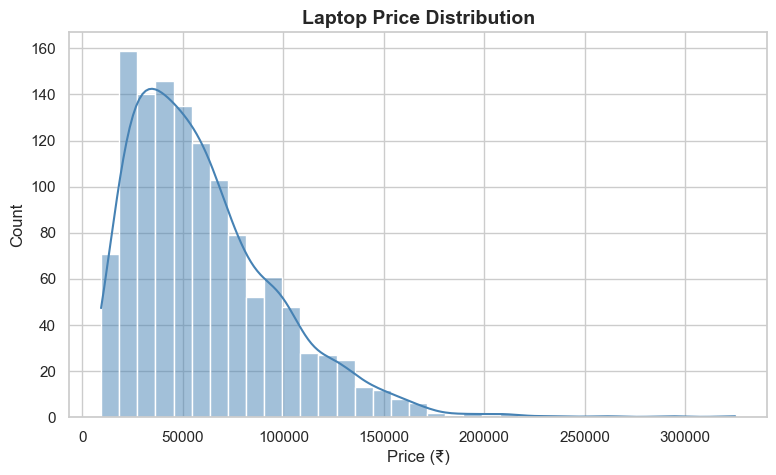

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Price"], bins=35, kde=True, color="steelblue")
plt.title("Laptop Price Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Price (₹)"); plt.ylabel("Count")
plt.show()

## 12. EDA – Laptops per Company

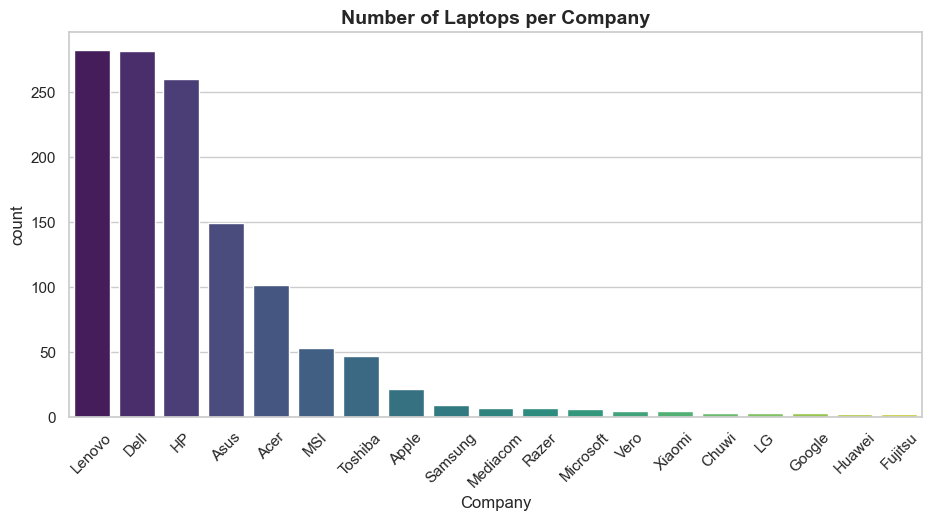

In [12]:
plt.figure(figsize=(11, 5))
order = df["Company"].value_counts().index
sns.countplot(x="Company", data=df, order=order, palette="viridis")
plt.title("Number of Laptops per Company", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

## 13. EDA – Price by Company (Box Plot)

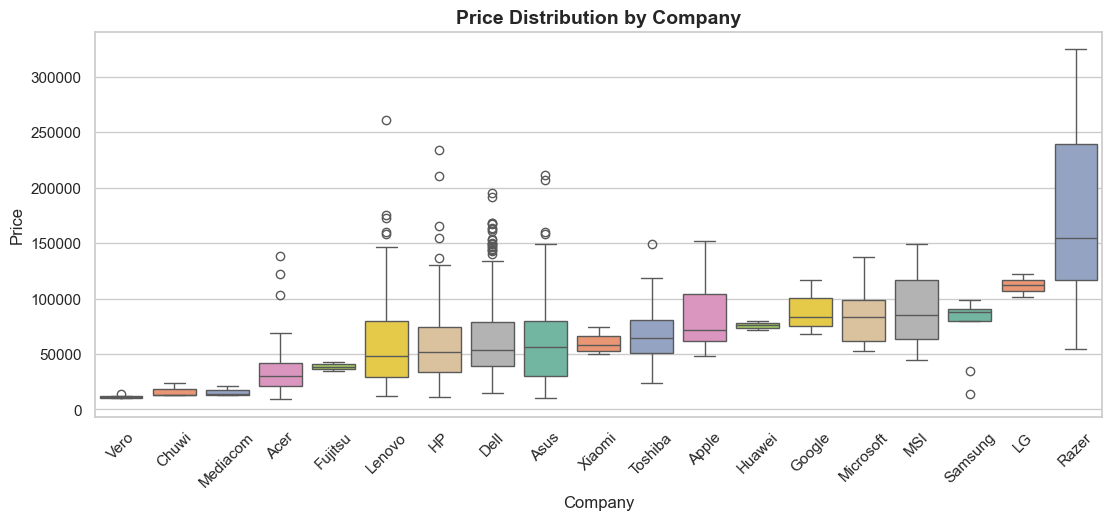

In [13]:
med_order = df.groupby("Company")["Price"].median().sort_values().index
plt.figure(figsize=(13, 5))
sns.boxplot(x="Company", y="Price", data=df, order=med_order, palette="Set2")
plt.title("Price Distribution by Company", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

## 14. EDA – Price by Laptop Type

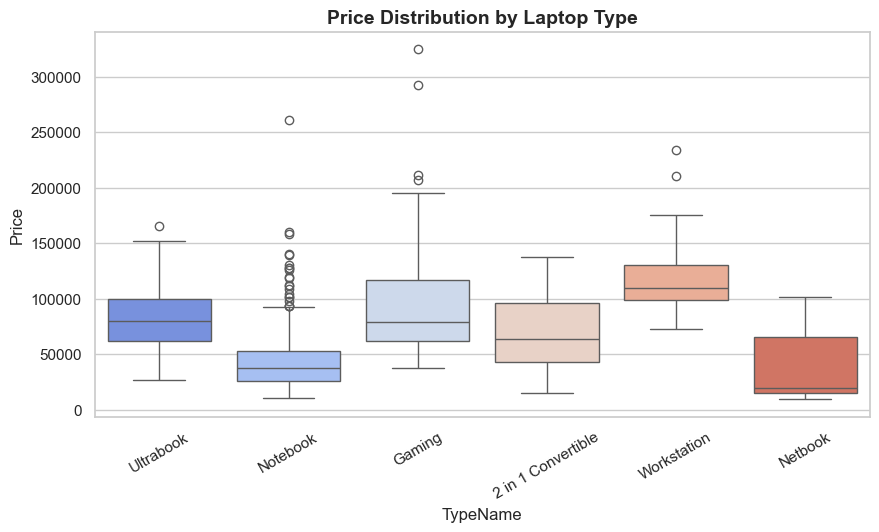

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="TypeName", y="Price", data=df, palette="coolwarm")
plt.title("Price Distribution by Laptop Type", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.show()

## 15. EDA – Price vs RAM

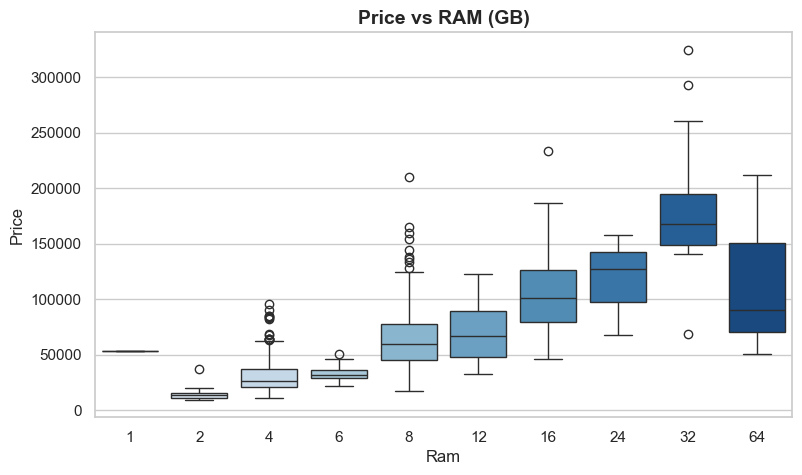

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="Ram", y="Price", data=df, palette="Blues")
plt.title("Price vs RAM (GB)", fontsize=14, fontweight="bold")
plt.show()

## 16. EDA – Price vs Operating System

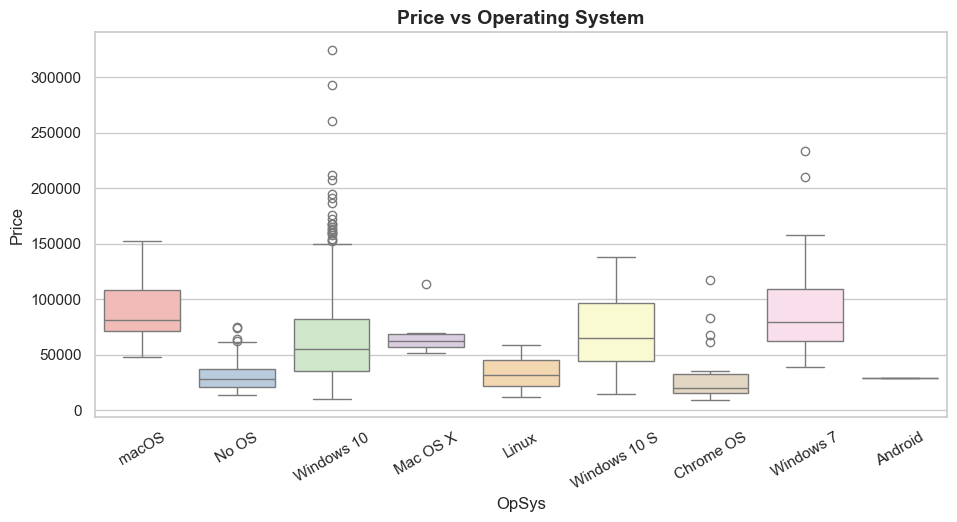

In [16]:
plt.figure(figsize=(11, 5))
sns.boxplot(x="OpSys", y="Price", data=df, palette="Pastel1")
plt.title("Price vs Operating System", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.show()

## 17. EDA – Correlation Heatmap

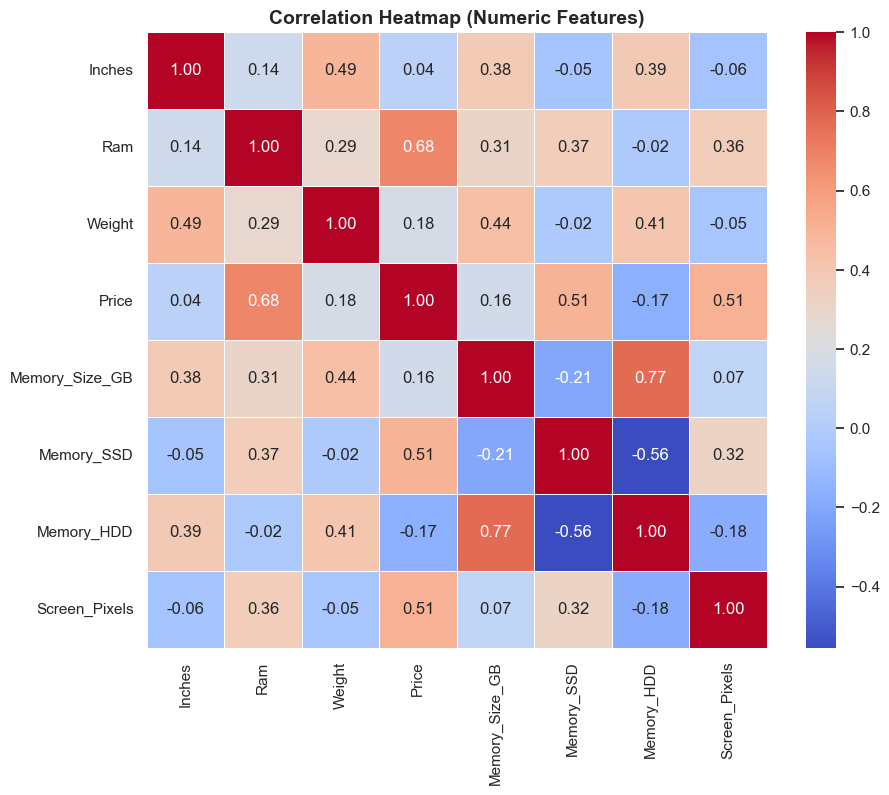

In [17]:
num_cols = ["Inches", "Ram", "Weight", "Price",
            "Memory_Size_GB", "Memory_SSD", "Memory_HDD", "Screen_Pixels"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)", fontsize=14, fontweight="bold")
plt.show()

## 18. Price Category (for Classification)
Bin price into **Budget / Mid-range / High-end**.

Price_Category
Mid-range    583
High-end     395
Budget       266
Name: count, dtype: int64


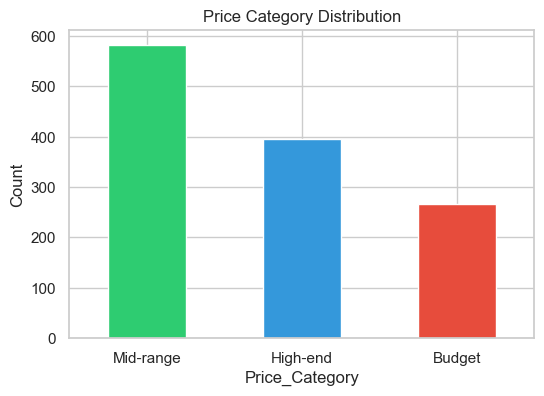

In [18]:
price_bins   = [0, 30000, 70000, df["Price"].max() + 1]
price_labels = ["Budget", "Mid-range", "High-end"]
df["Price_Category"] = pd.cut(df["Price"], bins=price_bins, labels=price_labels)

print(df["Price_Category"].value_counts())

plt.figure(figsize=(6, 4))
df["Price_Category"].value_counts().plot(kind="bar", color=["#2ecc71","#3498db","#e74c3c"])
plt.title("Price Category Distribution")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

## 19. Label Encoding

In [19]:
cat_cols = ["Company", "TypeName", "OpSys", "CPU_Brand", "GPU_Brand"]
df_enc = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col + "_enc"] = le.fit_transform(df_enc[col].astype(str))

print("Encoded columns added ✔")
df_enc[[c + "_enc" for c in cat_cols]].head()

Encoded columns added ✔


,Company_enc,TypeName_enc,OpSys_enc,CPU_Brand_enc,GPU_Brand_enc
0,1,4,8,1,2
1,1,4,8,1,2
2,7,3,4,1,2
3,1,4,8,1,0
4,1,4,8,1,2


## 20. Classification – Predict Price Category
Model: **Random Forest Classifier**

In [20]:
FEATURE_COLS = [
    "Inches", "Ram", "Weight",
    "Memory_Size_GB", "Memory_SSD", "Memory_HDD", "Screen_Pixels",
    "Company_enc", "TypeName_enc", "OpSys_enc",
    "CPU_Brand_enc", "GPU_Brand_enc",
]

X     = df_enc[FEATURE_COLS].fillna(0)
y_cat = LabelEncoder().fit_transform(df_enc["Price_Category"].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

print(f"✅ Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["Budget","High-end","Mid-range"]))

✅ Accuracy : 0.8233

              precision    recall  f1-score   support

      Budget       0.80      0.83      0.81        53
    High-end       0.84      0.86      0.85        79
   Mid-range       0.82      0.79      0.81       117

    accuracy                           0.82       249
   macro avg       0.82      0.83      0.82       249
weighted avg       0.82      0.82      0.82       249



## 21. Confusion Matrix – Classification

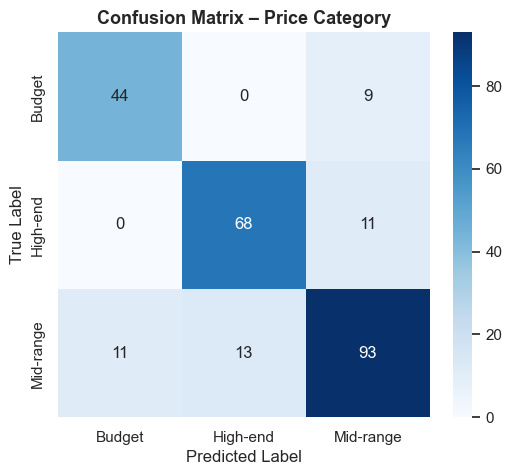

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Budget","High-end","Mid-range"],
            yticklabels=["Budget","High-end","Mid-range"])
plt.title("Confusion Matrix – Price Category", fontsize=13, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.show()

## 22. Feature Importance – Classifier

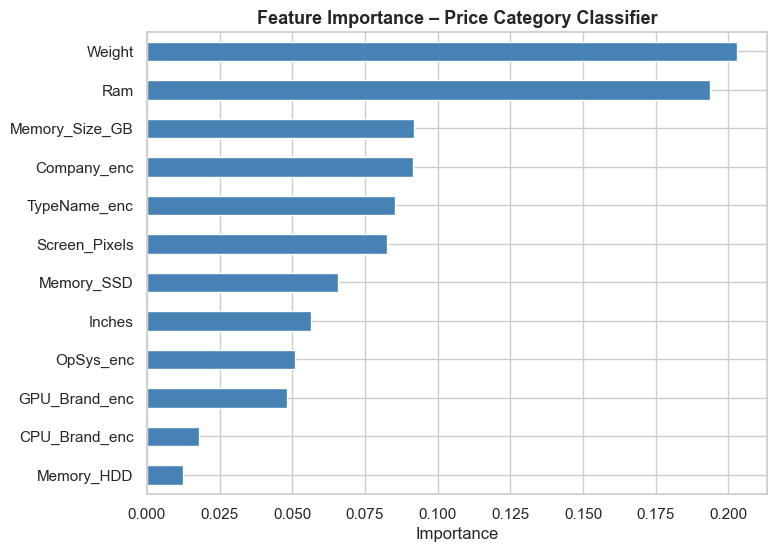

In [22]:
fi = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(8, 6))
fi.plot(kind="barh", color="steelblue")
plt.title("Feature Importance – Price Category Classifier", fontsize=13, fontweight="bold")
plt.xlabel("Importance")
plt.show()

## 23. Regression – Predict Exact Price
Model: **Random Forest Regressor**

In [23]:
y_reg = df_enc["Price"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_r = rf_reg.predict(X_test_r)

mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print(f"✅ MAE  : {mae:,.0f}")
print(f"✅ RMSE : {rmse:,.0f}")
print(f"✅ R²   : {r2:.4f}")

✅ MAE  : 10,903
✅ RMSE : 17,863
✅ R²   : 0.7262


## 24. Actual vs Predicted Price (Scatter)

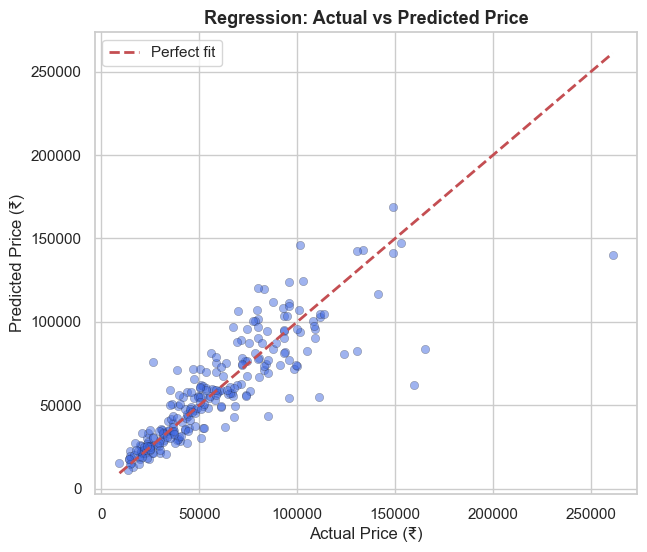

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, edgecolors="k", linewidths=0.3, color="royalblue")
mn, mx = float(y_test_r.min()), float(y_test_r.max())
plt.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual Price (₹)"); plt.ylabel("Predicted Price (₹)")
plt.title("Regression: Actual vs Predicted Price", fontsize=13, fontweight="bold")
plt.legend()
plt.show()

## 25. Feature Importance – Regressor

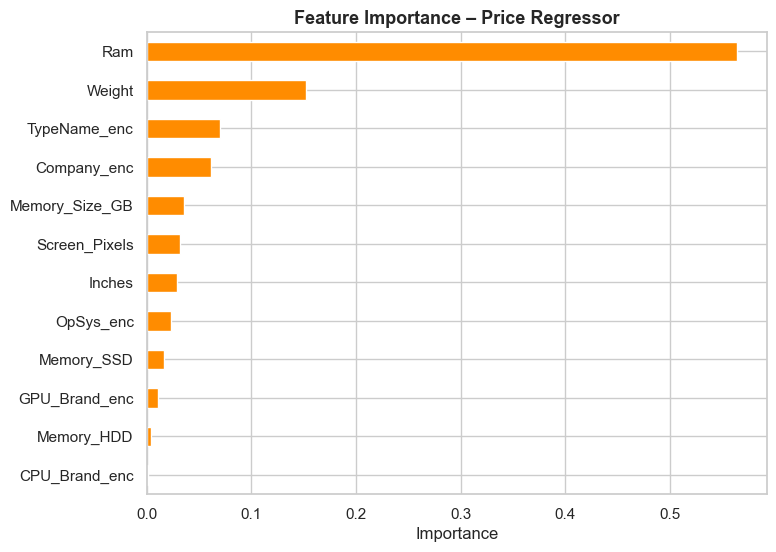

In [25]:
fi_r = pd.Series(rf_reg.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(8, 6))
fi_r.plot(kind="barh", color="darkorange")
plt.title("Feature Importance – Price Regressor", fontsize=13, fontweight="bold")
plt.xlabel("Importance")
plt.show()

## 26. Save Cleaned Dataset

In [26]:
out_path = os.path.join(BASE_DIR, "laptopData_cleaned_final.csv")
df.to_csv(out_path, index=False)
print(f"✅ Saved: {out_path}")
print(f"   Final shape: {df.shape}")

✅ Saved: C:\Users\solo\OneDrive\Desktop\Data Science Project\major project3\laptopData_cleaned_final.csv
   Final shape: (1244, 20)


---
## ✅ Analysis Complete!
- **Classification accuracy**: ~82%  
- **Regression R²**: ~0.73  
- Cleaned CSV saved as `laptopData_cleaned.csv`